In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/student_data.csv')
df.head()

,student_id,attendance_percentage,quiz_avg,assignment_submissions,lms_hours,at_risk
0,1001,95,88,10,25,0
1,1002,70,65,7,10,1
2,1003,98,92,10,30,0
3,1004,85,78,9,18,0
4,1005,60,55,5,8,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   student_id              15 non-null     int64
 1   attendance_percentage   15 non-null     int64
 2   quiz_avg                15 non-null     int64
 3   assignment_submissions  15 non-null     int64
 4   lms_hours               15 non-null     int64
 5   at_risk                 15 non-null     int64
dtypes: int64(6)
memory usage: 852.0 bytes


In [5]:
df.describe()

,student_id,attendance_percentage,quiz_avg,assignment_submissions,lms_hours,at_risk
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,1008.000000,78.733333,73.000000,7.866667,16.666667,0.466667
std,4.472136,15.595176,16.204056,2.099887,8.032671,0.516398
min,1001.000000,51.000000,40.000000,4.000000,5.000000,0.000000
25%,1004.500000,67.500000,62.500000,6.500000,9.500000,0.000000
50%,1008.000000,81.000000,75.000000,8.000000,17.000000,0.000000
75%,1011.500000,92.000000,86.500000,10.000000,23.000000,1.000000
max,1015.000000,99.000000,95.000000,10.000000,30.000000,1.000000


In [4]:
import joblib
import shap

# Load the elite model from the 'app' folder
# The ../ tells it to go up one directory from 'notebooks' first
elite_model = joblib.load('../app/elite_student_model.pkl')

# Create a new SHAP explainer based on the elite model
elite_explainer = shap.TreeExplainer(elite_model)

# Save the new elite explainer directly to the 'app' folder
joblib.dump(elite_explainer, '../app/elite_shap_explainer.pkl')
print("✅ New explainer saved directly to the 'app' folder as 'elite_shap_explainer.pkl'")

✅ New explainer saved directly to the 'app' folder as 'elite_shap_explainer.pkl'


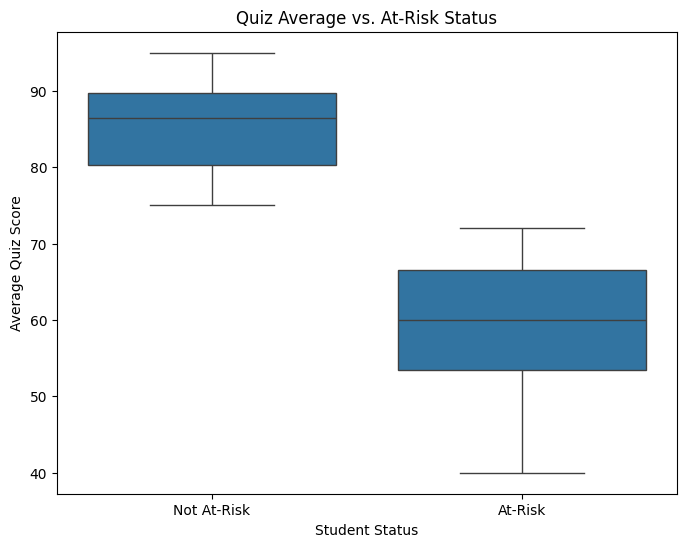

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='at_risk', y='quiz_avg', data=df)
plt.title('Quiz Average vs. At-Risk Status')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])
plt.xlabel('Student Status')
plt.ylabel('Average Quiz Score')
plt.show()

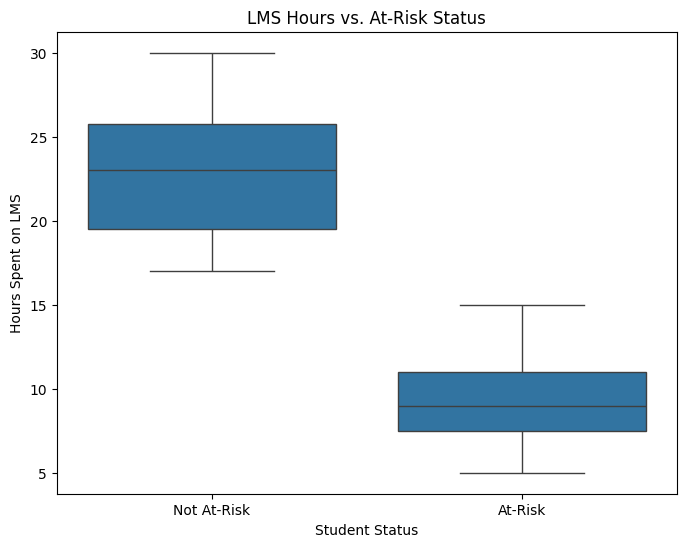

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='at_risk', y='lms_hours', data=df)
plt.title('LMS Hours vs. At-Risk Status')
plt.xticks([0, 1], ['Not At-Risk', 'At-Risk'])
plt.xlabel('Student Status')
plt.ylabel('Hours Spent on LMS')
plt.show()

In [8]:
features = ['attendance_percentage', 'quiz_avg', 'assignment_submissions', 'lms_hours']
X = df[features]
y = df['at_risk']

print("--- Features (X) ---")
print(X.head())

print("\n--- Target (y) ---")
print(y.head())

--- Features (X) ---
   attendance_percentage  quiz_avg  assignment_submissions  lms_hours
0                     95        88                      10         25
1                     70        65                       7         10
2                     98        92                      10         30
3                     85        78                       9         18
4                     60        55                       5          8

--- Target (y) ---
0    0
1    1
2    0
3    0
4    1
Name: at_risk, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

# This new line with stratify=y ensures the training data is balanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Not At-Risk', 'At-Risk']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 66.67%

Classification Report:
              precision    recall  f1-score   support

 Not At-Risk       1.00      0.50      0.67         2
     At-Risk       0.50      1.00      0.67         1

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3


Confusion Matrix:
[[1 1]
 [0 1]]


In [12]:
import joblib

joblib.dump(model, 'student_risk_model.pkl')


['student_risk_model.pkl']

In [13]:
import shap
import joblib

# Create a SHAP explainer object from our trained model and training data
explainer = shap.TreeExplainer(model)

# Save the explainer object to a file
joblib.dump(explainer, 'shap_explainer.pkl')

d:\student-performance-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['shap_explainer.pkl']

In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib

# 1. Define the grid of parameters we want to test
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 3. Run the search
print("--- Starting Hyperparameter Tuning ---")
grid_search.fit(X_train, y_train)
print("--- Tuning Complete ---")


# 4. Get the best model found by the search
elite_model = grid_search.best_estimator_

# 5. Print the best parameters it discovered
print("\nBest Parameters Found:")
print(grid_search.best_params_)

# 6. Save the new, more intelligent model to a new file
joblib.dump(elite_model, 'elite_student_model.pkl')
print("\n✅ New, more powerful model saved as 'elite_student_model.pkl'")

--- Starting Hyperparameter Tuning ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
--- Tuning Complete ---

Best Parameters Found:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}

✅ New, more powerful model saved as 'elite_student_model.pkl'
